## Introduction: Noise Data Analysis and Max Slow Prediction

This notebook is dedicated to an in-depth analysis of noise data, with the primary objective of building a robust regression model to predict the `max_slow` variable. The `max_slow` variable is a critical indicator in noise analysis, representing the maximum noise level over a slow time weighting. Understanding and predicting this metric is crucial for environmental impact assessments, regulatory compliance, and operational planning, especially in aviation or industrial settings.

The analysis presented herein follows a structured machine learning workflow, encompassing several key stages:

1.  **Environment Setup and Data Loading:** Initializing the necessary libraries and loading the raw noise dataset.
2.  **Initial Data Inspection and Cleaning:** Understanding the dataset's structure, handling missing values, and preparing the data for further processing.
3.  **Target Variable Analysis (`max_slow`):** A deep dive into the distribution and characteristics of the `max_slow` variable, including statistical tests for normality.
4.  **Feature Engineering:** Creating new, informative features from existing data, particularly from timestamps, to capture temporal patterns and operational characteristics.
5.  **Group-wise Analysis and Feature Creation:** Examining `max_slow` distributions across different aircraft types and models, and deriving new binary features like `takeoff` to capture specific noise events.
6.  **Clustering Aircraft Types:** Grouping similar aircraft types based on their noise characteristics using K-Means clustering to create a new categorical feature.
7.  **Correlation Analysis and Statistical Tests:** Investigating relationships between features and the target variable using correlation heatmaps and non-parametric statistical tests.
8.  **Model Training and Evaluation:** Splitting the data, training several baseline regression models (e.g., RandomForest, ElasticNet, K-Neighbors, XGBoost), and evaluating their performance using Mean Squared Error (MSE) and Mean Absolute Error (MAE).
9.  **Hyperparameter Tuning with Optuna:** Utilizing the Optuna framework to systematically optimize the hyperparameters of the best-performing model (XGBoost) to achieve minimal MSE.
10. **Conclusion and Further Development:** Summarizing the findings and outlining potential next steps and areas for future research and model improvement.

Through this comprehensive approach, we aim to develop an accurate predictive model for `max_slow`, providing valuable insights into noise patterns and contributing to better noise management strategies.

# Noise Data Analysis and Max Slow Prediction

This notebook performs an exploratory data analysis (EDA) and builds a regression model to predict the `max_slow` variable from a dataset related to aircraft noise. The process includes data loading, cleaning, feature engineering, statistical analysis, baseline model training, and hyperparameter optimization using Optuna.

In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
from plotly.offline import iplot, init_notebook_mode
from scipy.optimize import minimize
import itertools
import datetime as dt
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from scipy.stats import shapiro
from sklearn import ensemble, tree, linear_model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
!pip install optuna
import optuna
from sklearn.metrics import precision_score,recall_score
from sklearn.metrics import f1_score

## 1. Environment Setup and Data Loading

This section imports all necessary libraries for data manipulation, visualization, statistical analysis, and machine learning. It also loads the dataset from the specified CSV file.

In [5]:
train = pd.read_csv('/content/noise_data_test.csv')

## 2. Initial Data Inspection and Cleaning

Here, we perform initial checks on the dataset to understand its structure, identify missing values, and preview the first few rows. The `Unnamed: 0` column, which appears to be an index, is dropped.

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6673 entries, 0 to 6672
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6673 non-null   int64  
 1   timestamp   6673 non-null   object 
 2   max_slow    6673 non-null   float64
 3   type        6673 non-null   object 
 4   model       6673 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 260.8+ KB


In [7]:
print(f'\033[94mNumber of dataset rows: {train.shape[0]}')
print(f'\033[94mNumber of dataset columns: {train.shape[1]}')
print(f'\033[94mNumber of missing values: {sum(train.isna().sum())}')

Number of dataset rows: 6673
Number of dataset columns: 5
Number of missing values: 0


In [8]:
train.head(20)

,Unnamed: 0,timestamp,max_slow,type,model
0,0,2022-03-01 00:03:47,70.800003,B738,Boeing 737-800
1,1,2022-03-01 00:05:02,69.199997,B738,Boeing 737-800
2,2,2022-03-01 00:06:24,69.599998,B738,Boeing 737-800
3,3,2022-03-01 00:09:47,71.500000,B738,Boeing 737-800
4,4,2022-03-01 00:11:43,70.800003,B738,Boeing 737-800
5,5,2022-03-01 00:22:57,71.099998,B738,Boeing 737-800
6,6,2022-03-01 00:44:23,71.400002,B738,Boeing 737-800
7,7,2022-03-01 00:46:09,73.500000,B77W,Boeing 777-300ER
8,8,2022-03-01 00:57:28,69.300003,B738,Boeing 737-800
9,9,2022-03-01 01:07:35,62.700001,E35L,Embraer Legacy 600


In [9]:
train.columns

Index(['Unnamed: 0', 'timestamp', 'max_slow', 'type', 'model'], dtype='object')

In [10]:
train.drop('Unnamed: 0',axis=1,inplace=True)

In [11]:
train.describe().style.background_gradient(cmap = 'Blues')

,max_slow
count,6673.000000
mean,68.477087
std,4.509026
min,50.599998
25%,65.099998
50%,68.300003
75%,72.000000
max,91.500000


A descriptive statistical summary of the numerical columns provides insights into the central tendency, dispersion, and shape of the data distribution.

In [12]:
train.type.unique()

array(['B738', 'B77W', 'E35L', 'CL60', 'B735', 'B752', 'B763', 'A148',
       'GL5T', 'F900', 'B762', 'A319', 'SU95', 'A320', 'C56X', 'IL96',
       'GLF4', 'GLF5', 'T204', 'CRJ2', 'B737', 'A333', 'B739', 'A332',
       'B734', 'PC12', 'A310', 'H25B', 'FA7X', 'GLF6', 'B789', 'CRJ1',
       'C25B', 'A321', 'E190', 'A21N', 'GLEX', 'E75L', 'A318', 'A343',
       'B733', 'A346', 'IL76', 'B788', 'A20N', 'B742'], dtype=object)

In [13]:
train.type.nunique()

46

Next, we examine the unique values and counts of categorical features like `type` and `model` to understand their diversity.

In [17]:
Plot_box_target(train,'max_slow')

## 3. Target Variable Analysis (`max_slow`)

This section focuses on understanding the distribution of the target variable `max_slow` using box plots, histograms, and density plots. A Shapiro-Wilk test is performed to check for normality.

In [18]:
def Plot_distribution_target(dataset,target):
  plt.figure(figsize=(30, 7))
  plt.title("{target} Distribution".format(target = target))
  sns.histplot(dataset[target], stat='density',color='blue')
  sns.kdeplot(dataset[target], color='black')
  plt.axvline(dataset[target].mean(), color='red', linestyle='--', linewidth=0.8)
  min_ylim, max_ylim = plt.ylim()
  plt.text(dataset[target].mean()*1.1, max_ylim*0.96, 'Mean (μ): {:.2f}'.format(dataset[target].mean()))
  plt.xlabel("Score")
  plt.ylabel("Density")
  return plt.show()

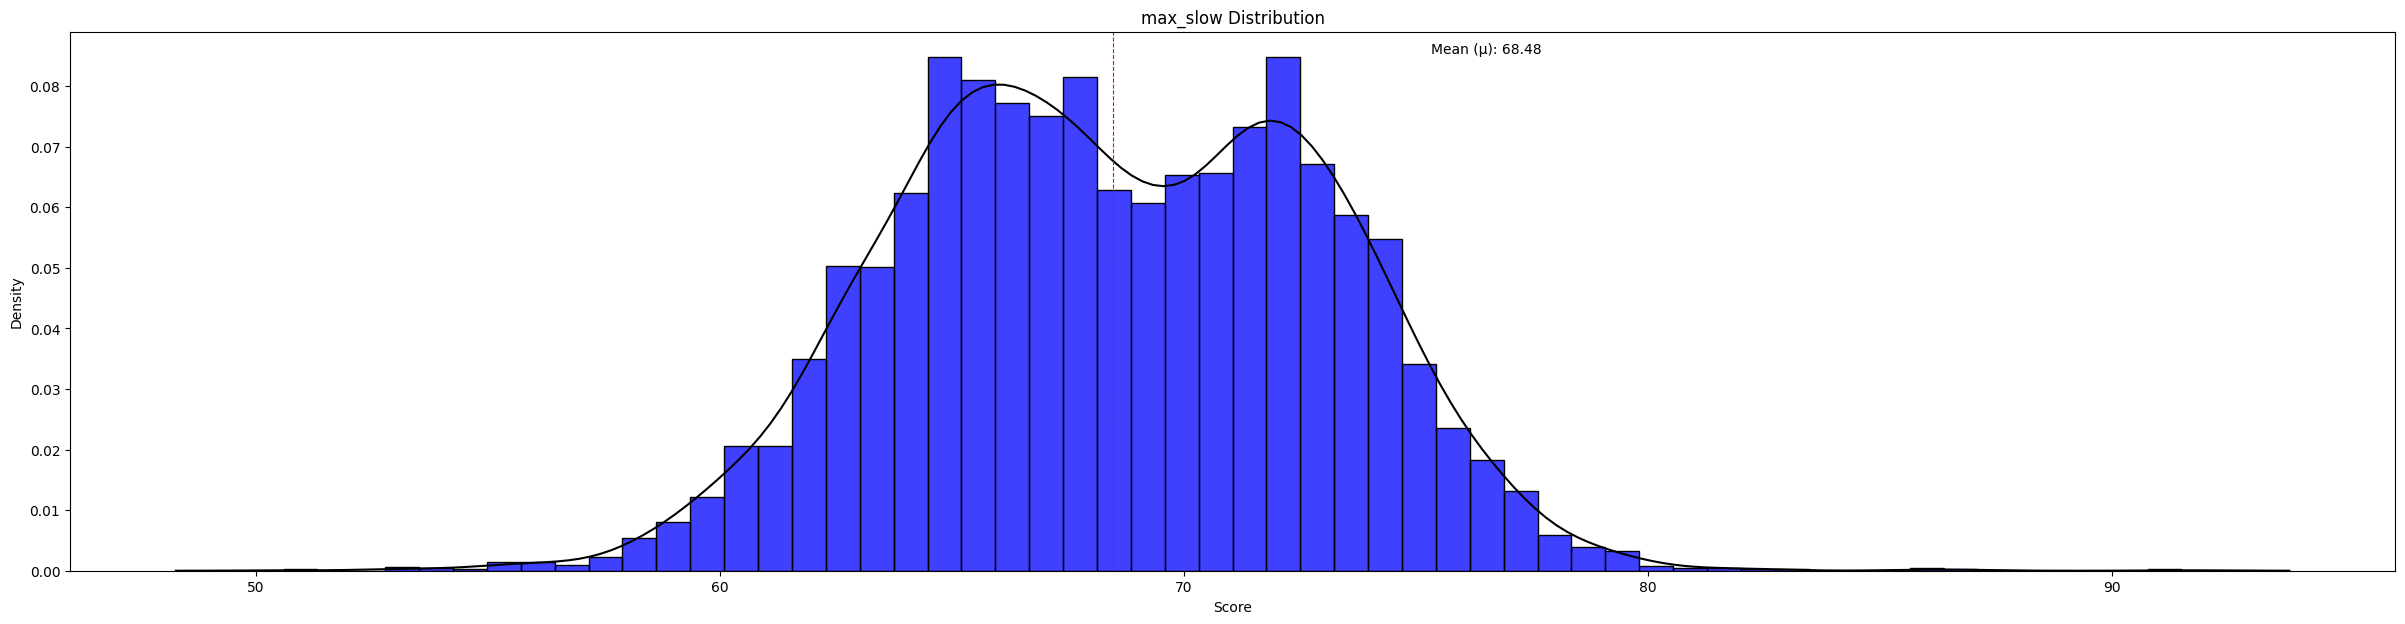

In [19]:
Plot_distribution_target(train,'max_slow')

The Shapiro-Wilk test indicates whether the `max_slow` distribution is Gaussian.

In [20]:
# Shapiro-Wilk Test
numeric=['max_slow']
# normality test
for feature in numeric:
	stat, p = shapiro(train[feature])
	print('Statistics=%.3f, p=%.3f' % (stat, p))
	# interpret
	alpha = 0.05
	if p > alpha:
		print(f'Sample {feature} looks Gaussian (fail to reject H0),')
	else:
		print(f'Sample {feature} does not look Gaussian (reject H0)')

Statistics=0.993, p=0.000
Sample max_slow does not look Gaussian (reject H0)


In [21]:
def plot_vis_box(dataset,numeric,hue=None):
  i=1
  plt.figure(figsize=(15,25))
  for feature in numeric:
    plt.title("{feature} Distribution".format(feature = feature))
    plt.subplot(6,3,i)
    sns.boxplot(y=dataset[feature],color='green',hue=hue)
    i+=1
  plt.suptitle("Outlier visualizations (boxplot)",fontsize=20)
  return plt.show()

Box plots are used to visualize the distribution of `max_slow` across different aircraft models, helping to identify outliers and variations specific to each model.

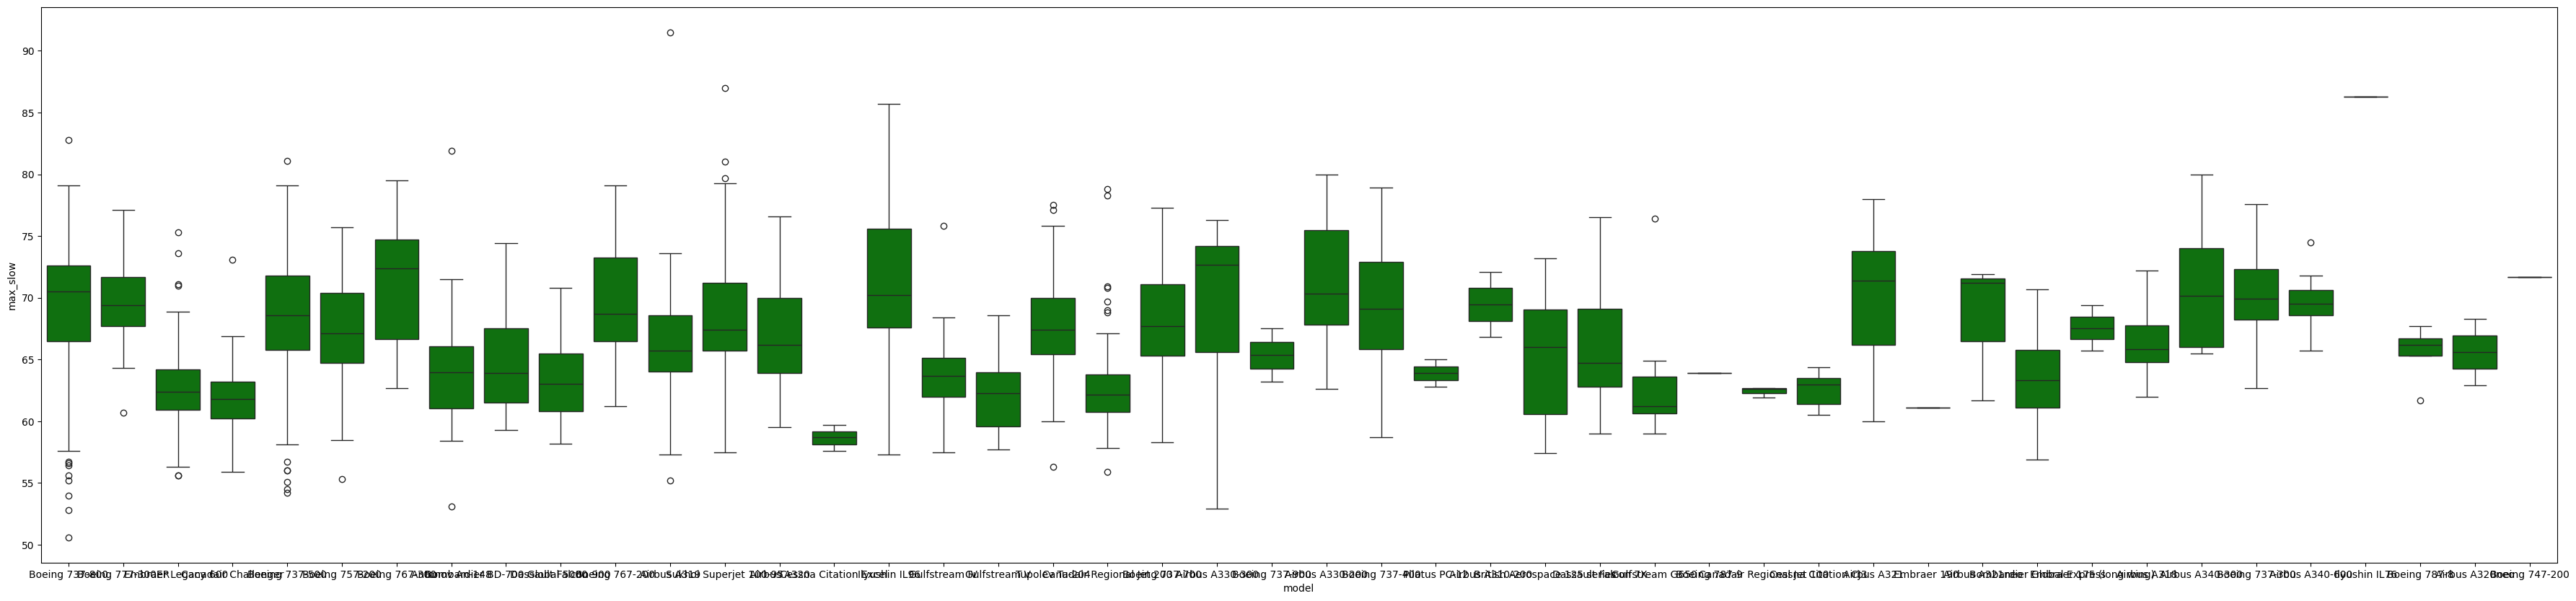

In [22]:
plt.figure(figsize=(45,10))
sns.boxplot(y='max_slow',color='green',x='model',data=train)
plt.show()

## 4. Feature Engineering: Date and Time Features

The `timestamp` column is converted to datetime objects, and new features like `year`, `day`, `month`, `hour`, and `day_of_week` are extracted to capture temporal patterns.

In [23]:
def DateTimes(dataset,feature):
  dataset[feature]=pd.to_datetime(dataset[feature], format = '%Y-%m-%d %H:%M:%S')
  dataset['year']=dataset[feature].dt.year
  dataset['day']=dataset[feature].dt.day
  dataset['month']=dataset[feature].dt.month
  dataset['hour']=dataset[feature].dt.hour
  dataset['day_of_week']=dataset[feature].dt.dayofweek
  return dataset

In [24]:
DateTimes(train,'timestamp')

,timestamp,max_slow,type,model,year,day,month,hour,day_of_week
0,2022-03-01 00:03:47,70.800003,B738,Boeing 737-800,2022,1,3,0,1
1,2022-03-01 00:05:02,69.199997,B738,Boeing 737-800,2022,1,3,0,1
2,2022-03-01 00:06:24,69.599998,B738,Boeing 737-800,2022,1,3,0,1
3,2022-03-01 00:09:47,71.500000,B738,Boeing 737-800,2022,1,3,0,1
4,2022-03-01 00:11:43,70.800003,B738,Boeing 737-800,2022,1,3,0,1
...,...,...,...,...,...,...,...,...,...
6668,2022-05-28 22:56:30,66.000000,A148,Antonov An-148,2022,28,5,22,5
6669,2022-05-28 23:15:36,68.000000,B735,Boeing 737-500,2022,28,5,23,5
6670,2022-05-28 23:27:51,69.400002,SU95,Sukhoi Superjet 100-95,2022,28,5,23,5
6671,2022-05-28 23:40:33,66.500000,B738,Boeing 737-800,2022,28,5,23,5


Time-series plots are generated to visualize the trend of `max_slow` over different temporal granularities (month, day, hour, day of week), revealing potential seasonality or daily patterns.

In [25]:
def Plot_Timeseries(dataset,feature,time_feature,hue=None):
   plt.figure(figsize=(15,8))
   if hue==None:
     sns.lineplot(data=dataset,x=time_feature,y=feature,hue=hue,palette='dark').set_title(f'Distribution of target variable {feature}')
   else:
     sns.lineplot(data=dataset,x=time_feature,y=feature,hue=hue,palette='dark').set_title(f'Distribution of target variable {feature} depending on {hue}')
   plt.grid()
   return plt.show()

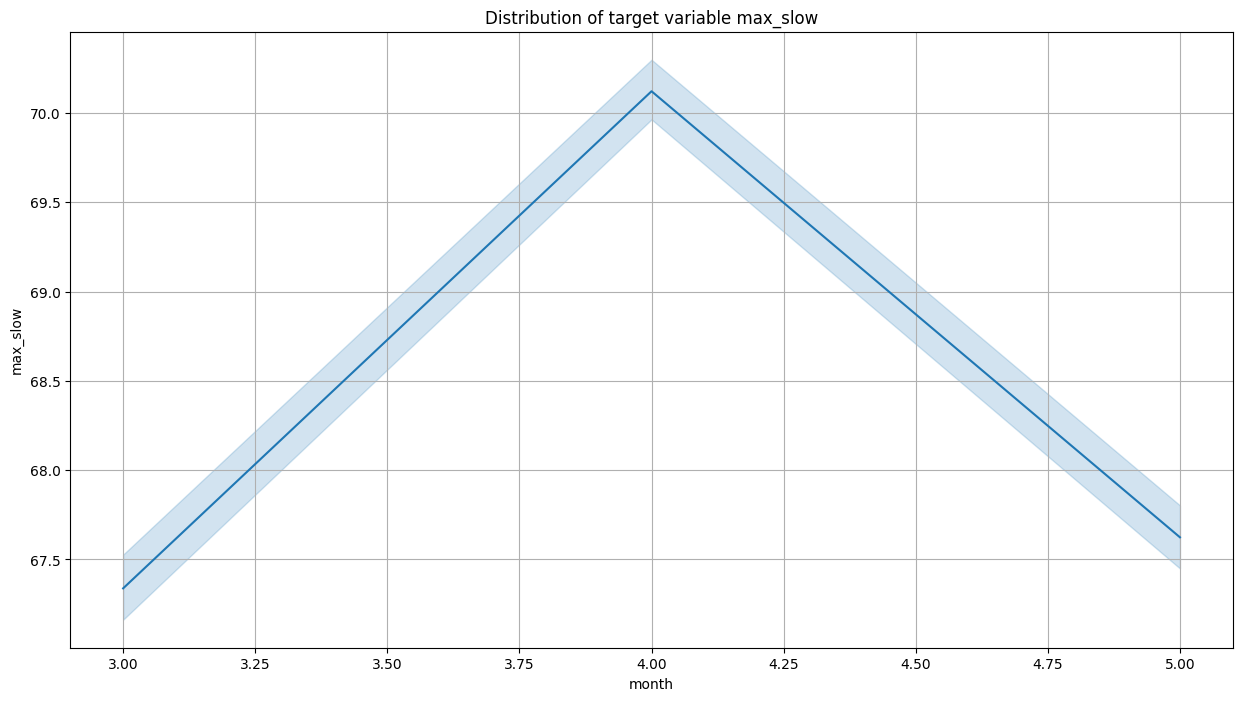

In [26]:
Plot_Timeseries(train,'max_slow','month')

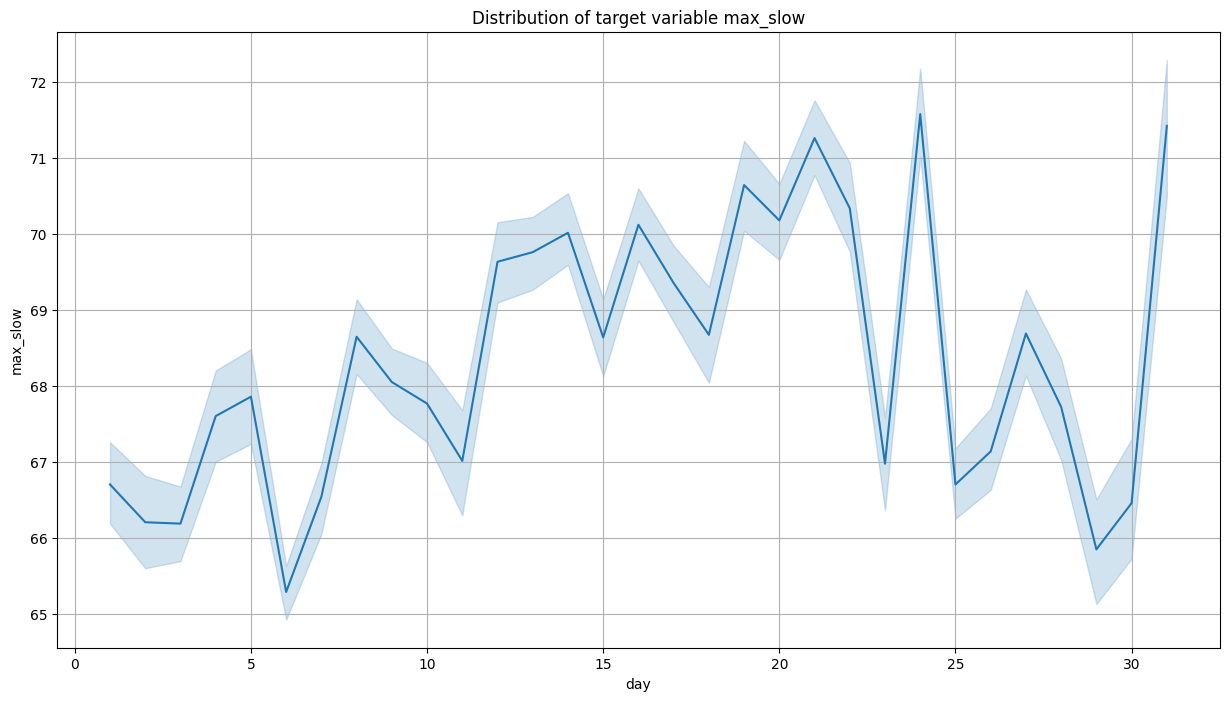

In [27]:
Plot_Timeseries(train,'max_slow','day')

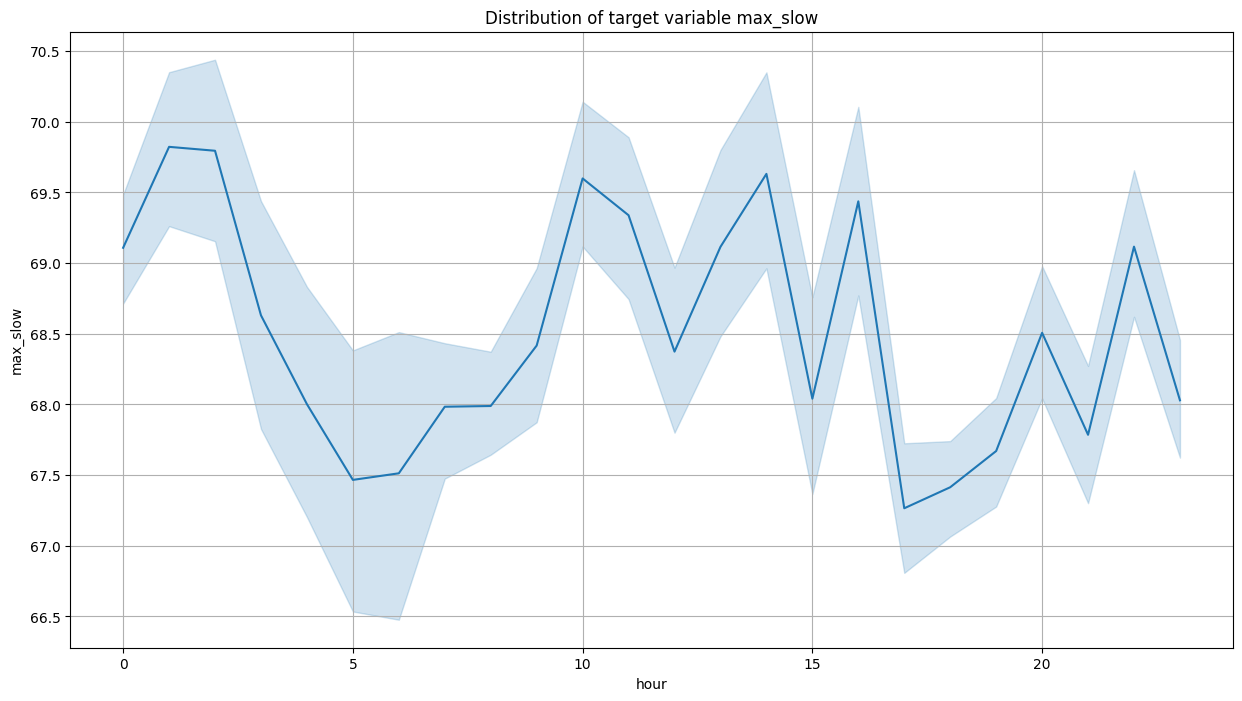

In [28]:
Plot_Timeseries(train,'max_slow','hour')

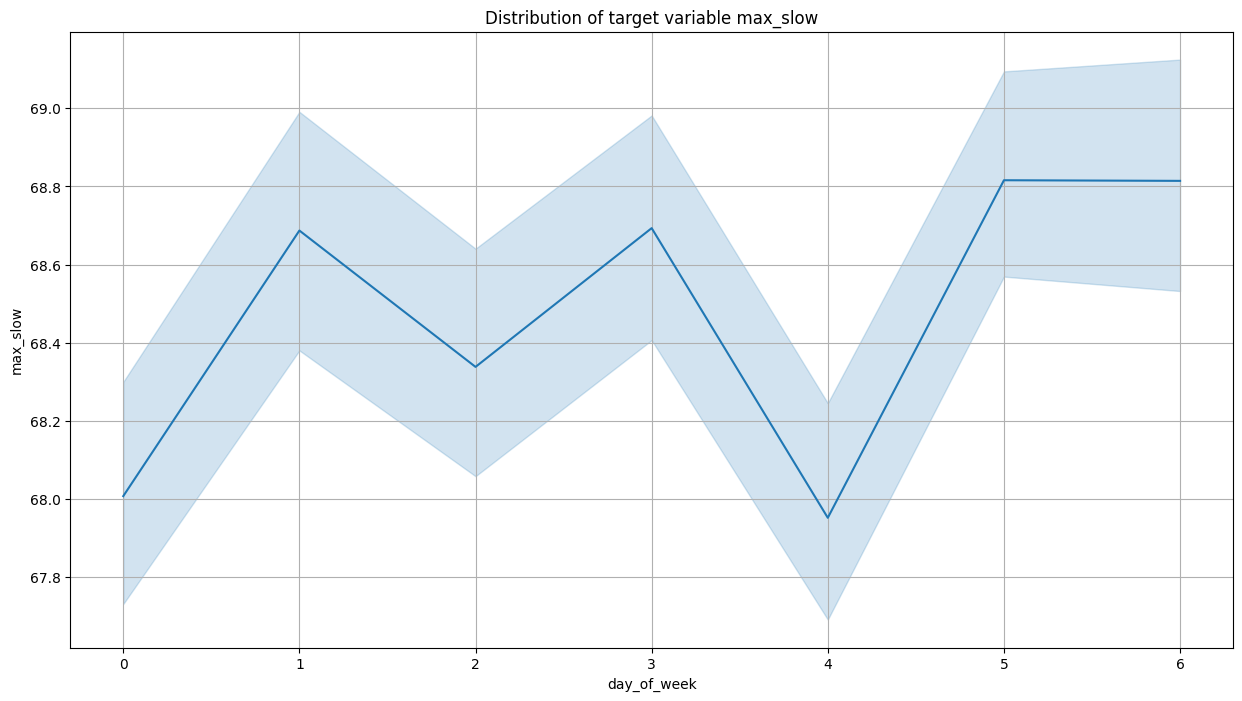

In [29]:
Plot_Timeseries(train,'max_slow','day_of_week')

## 5. Group-wise Analysis and Feature Creation

This section performs grouped analysis of `max_slow` by aircraft `type` and `model`, examining their distributions and creating new features.

In [30]:
def plot_vis_distr(dataset,target,condition_feature):
   i=1
   plt.figure(figsize=(15,25))
   for feature in dataset[condition_feature].unique():
     plt.subplot(20,3,i)
     sns.histplot(dataset[target][dataset[condition_feature] == feature], stat='density',color='blue')
     sns.kdeplot(dataset[target][dataset[condition_feature] == feature], color='black')
     i+=1
   plt.suptitle("Visualization of continuous variables depending on aircraft type",fontsize=20)
   return plt.show()

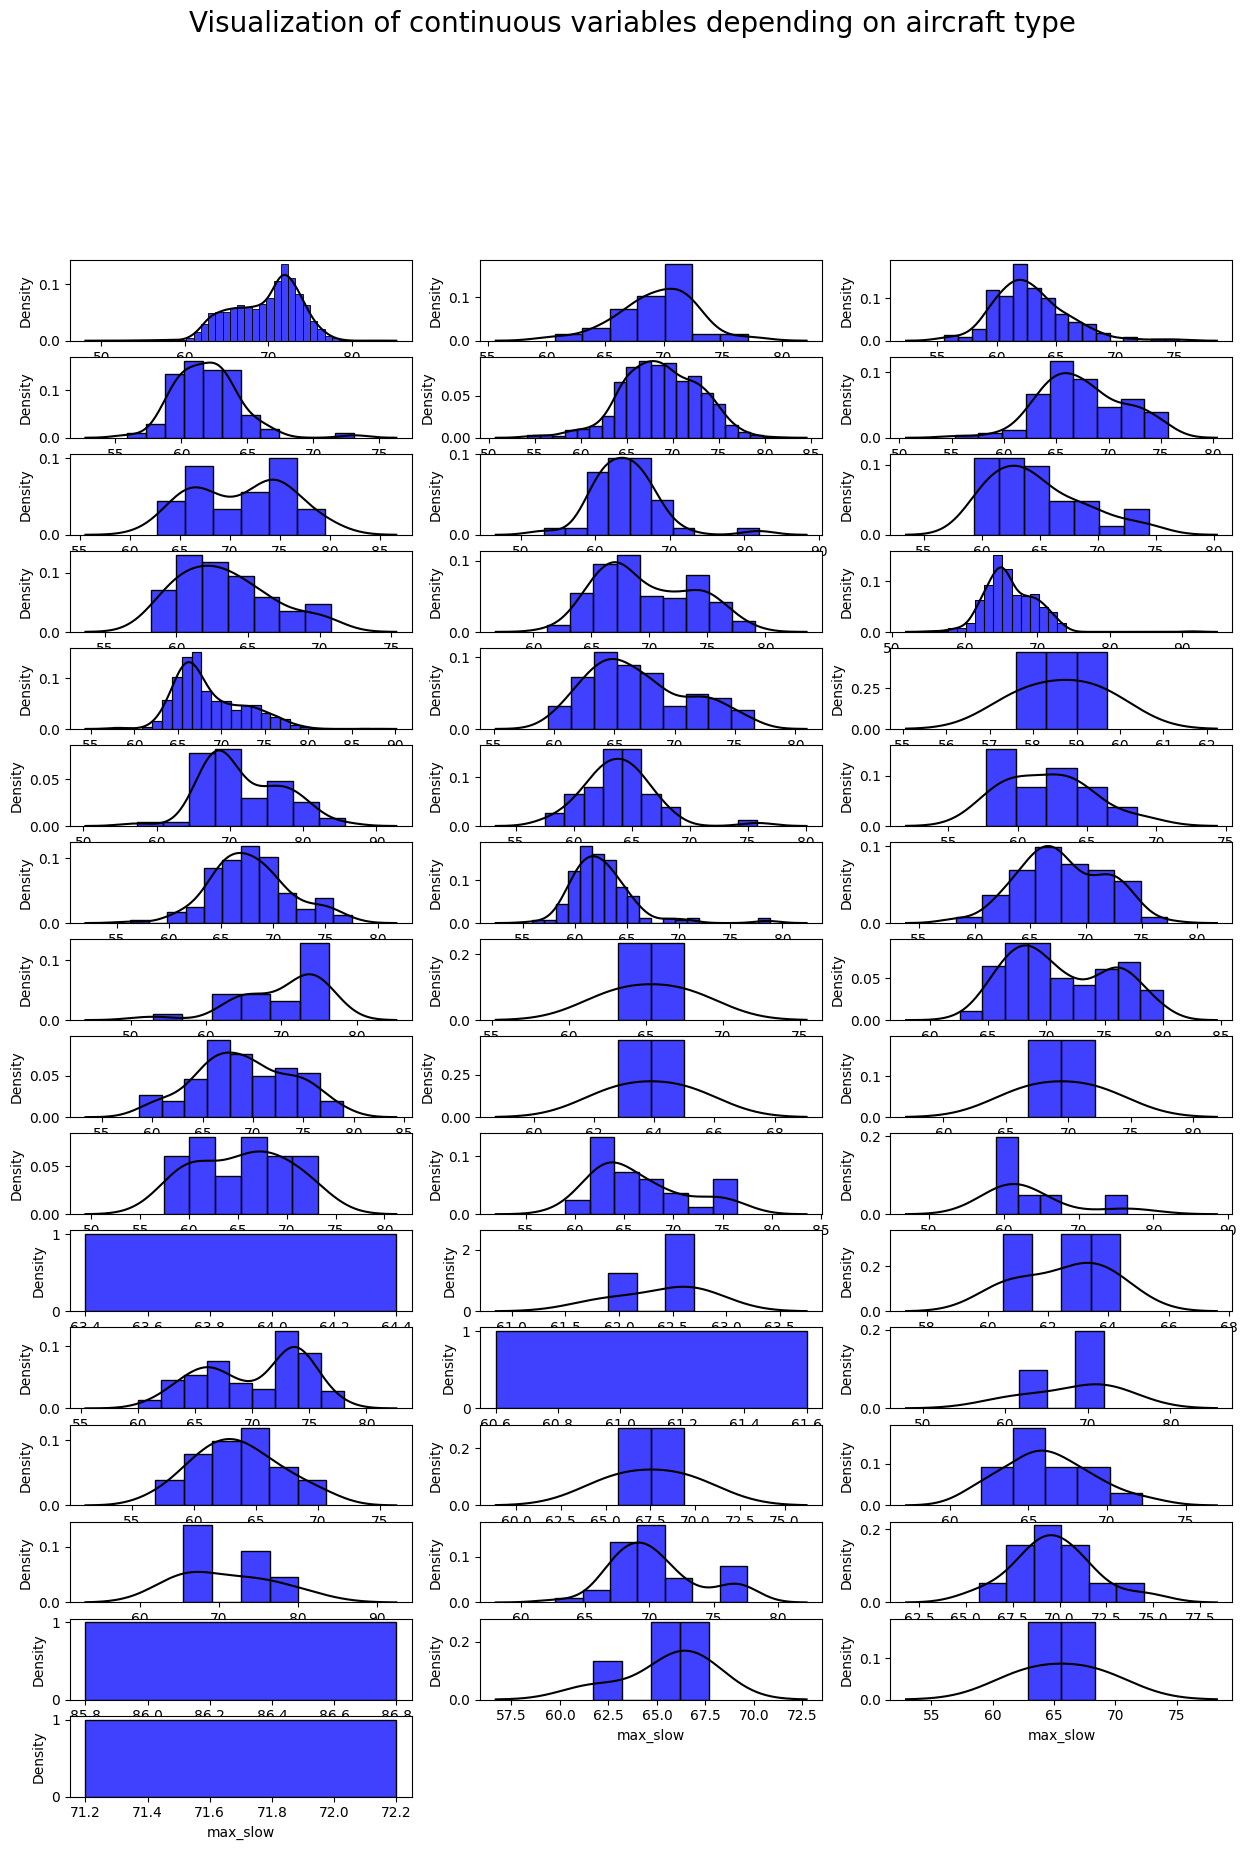

In [31]:
plot_vis_distr(train,'max_slow','type')

Statistical summaries (mean, median, variance) of `max_slow` are calculated for each aircraft type to understand their characteristic noise levels.

In [32]:
train.type.nunique()

46

In [33]:
train.model.nunique()

46

In [34]:
def stat_airplane(dataset,target,condition_feature):
   for feature in dataset[condition_feature].unique():
     sred=dataset[target][dataset[condition_feature] == feature].mean()
     sko=dataset[target][dataset[condition_feature] == feature].var()
     med=dataset[target][dataset[condition_feature] == feature].median()
     print(f'Aircraft type: {feature},\n arithmetic mean: {sred}, median: {med}, sample standard deviation: {sko}')
     print('='*50)

In [35]:
stat_airplane(train,'max_slow','type')

Aircraft type: B738,
 arithmetic mean: 69.61229382247582, median: 70.5, sample standard deviation: 16.20368819779511
Aircraft type: B77W,
 arithmetic mean: 69.41379297190699, median: 69.4000015258789, sample standard deviation: 10.725514460413537
Aircraft type: E35L,
 arithmetic mean: 62.805524625830884, median: 62.400001525878906, sample standard deviation: 9.236191663413035
Aircraft type: CL60,
 arithmetic mean: 61.95890395282066, median: 61.79999923706055, sample standard deviation: 6.214953593686915
Aircraft type: B735,
 arithmetic mean: 68.66196956634522, median: 68.5999984741211, sample standard deviation: 17.69280017896928
Aircraft type: B752,
 arithmetic mean: 67.48761030214023, median: 67.0999984741211, sample standard deviation: 15.911986494224752
Aircraft type: B763,
 arithmetic mean: 71.1812504529953, median: 72.4000015258789, sample standard deviation: 22.657699804309207
Aircraft type: A148,
 arithmetic mean: 64.04749984741211, median: 63.95000076293945, sample standard de

A binary `takeoff` feature is created based on whether `max_slow` is above or below the median `max_slow` for each aircraft type. This feature aims to capture instances of higher noise potentially associated with takeoff events.

In [36]:
def prisv_med (dataset,target,condition_feature):
  for feature in dataset[condition_feature].unique():
    dataset.loc[dataset[condition_feature] == feature, 'Mediana'] = dataset[target][dataset[condition_feature] == feature].median()
  dataset['takeoff'] = np.where(dataset[target]>=dataset['Mediana'], 1, 0)
  dataset.drop('Mediana',axis=1,inplace=True)
  return dataset

In [37]:
prisv_med (train,'max_slow','type')

,timestamp,max_slow,type,model,year,day,month,hour,day_of_week,takeoff
0,2022-03-01 00:03:47,70.800003,B738,Boeing 737-800,2022,1,3,0,1,1
1,2022-03-01 00:05:02,69.199997,B738,Boeing 737-800,2022,1,3,0,1,0
2,2022-03-01 00:06:24,69.599998,B738,Boeing 737-800,2022,1,3,0,1,0
3,2022-03-01 00:09:47,71.500000,B738,Boeing 737-800,2022,1,3,0,1,1
4,2022-03-01 00:11:43,70.800003,B738,Boeing 737-800,2022,1,3,0,1,1
...,...,...,...,...,...,...,...,...,...,...
6668,2022-05-28 22:56:30,66.000000,A148,Antonov An-148,2022,28,5,22,5,1
6669,2022-05-28 23:15:36,68.000000,B735,Boeing 737-500,2022,28,5,23,5,0
6670,2022-05-28 23:27:51,69.400002,SU95,Sukhoi Superjet 100-95,2022,28,5,23,5,1
6671,2022-05-28 23:40:33,66.500000,B738,Boeing 737-800,2022,28,5,23,5,0


Statistical summaries are then re-evaluated for the `takeoff=1` group (above median `max_slow`).

In [38]:
takeoff_1=train.loc[train['takeoff']==1]

In [39]:
stat_airplane(takeoff_1,'max_slow','type')

Aircraft type: B738,
 arithmetic mean: 72.89592280858, median: 72.5999984741211, sample standard deviation: 2.755198730218109
Aircraft type: B77W,
 arithmetic mean: 71.6749997138977, median: 71.64999771118164, sample standard deviation: 3.3113321991014044
Aircraft type: E35L,
 arithmetic mean: 65.04565189195716, median: 64.19999694824219, sample standard deviation: 5.880091239105191
Aircraft type: B735,
 arithmetic mean: 72.0033131105354, median: 71.75, sample standard deviation: 5.739535422405737
Aircraft type: B752,
 arithmetic mean: 70.64912227162144, median: 70.4000015258789, sample standard deviation: 6.688258656671222
Aircraft type: B763,
 arithmetic mean: 75.36250019073486, median: 74.75, sample standard deviation: 3.9945001169874255
Aircraft type: A148,
 arithmetic mean: 67.18499984741212, median: 66.1500015258789, sample standard deviation: 15.245557911124838
Aircraft type: F900,
 arithmetic mean: 65.94583368301392, median: 65.5, sample standard deviation: 5.902594128765094
Ai

Similarly, summaries for the `takeoff=0` group (below median `max_slow`) are examined.

In [40]:
takeoff_0=train.loc[train['takeoff']==0]
stat_airplane(takeoff_0,'max_slow','type')

Aircraft type: B738,
 arithmetic mean: 66.25398032569451, median: 66.5, sample standard deviation: 7.647934103120577
Aircraft type: CL60,
 arithmetic mean: 60.08333322736952, median: 60.14999961853027, sample standard deviation: 1.409999603999162
Aircraft type: E35L,
 arithmetic mean: 60.48988745185766, median: 60.79999923706055, sample standard deviation: 2.1422831789404415
Aircraft type: GL5T,
 arithmetic mean: 61.44999970330132, median: 61.25, sample standard deviation: 1.8402950197115973
Aircraft type: B735,
 arithmetic mean: 65.27987793015271, median: 65.80000305175781, sample standard deviation: 7.037575710050388
Aircraft type: B762,
 arithmetic mean: 66.18831188647778, median: 66.4000015258789, sample standard deviation: 2.4502567891013904
Aircraft type: A319,
 arithmetic mean: 63.553488332171774, median: 64.0, sample standard deviation: 2.9609823099591277
Aircraft type: SU95,
 arithmetic mean: 65.41646174775295, median: 65.5999984741211, sample standard deviation: 2.14502389524

A count plot shows the distribution of the newly created `takeoff` feature.

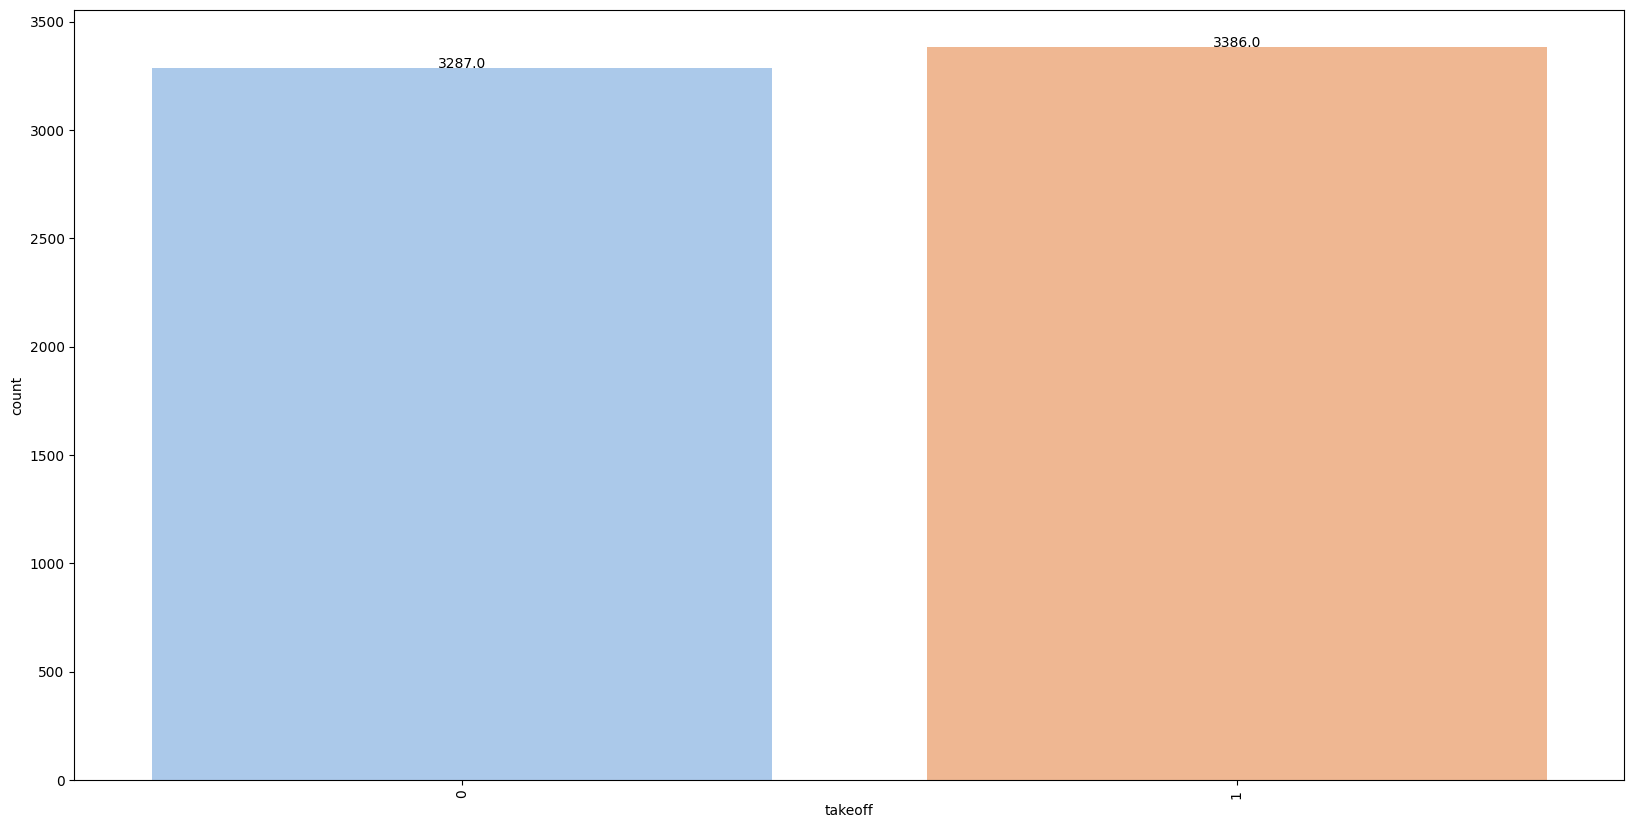

In [41]:
fig, ax1 = plt.subplots(figsize=(20,10))
graph = sns.countplot(ax=ax1,x = 'takeoff' , data = train,palette='pastel')
graph.set_xticklabels(graph.get_xticklabels(),rotation=90)
for p in graph.patches:
    height = p.get_height()
    graph.text(p.get_x()+p.get_width()/2., height + 0.1,height ,ha="center")

## 6. Clustering Aircraft Types

K-Means clustering is applied to the mean `max_slow` values of each aircraft type to group similar types together. The elbow method is used to determine an appropriate number of clusters.

In [43]:
Group_data = train.groupby('type')[['max_slow']].mean()

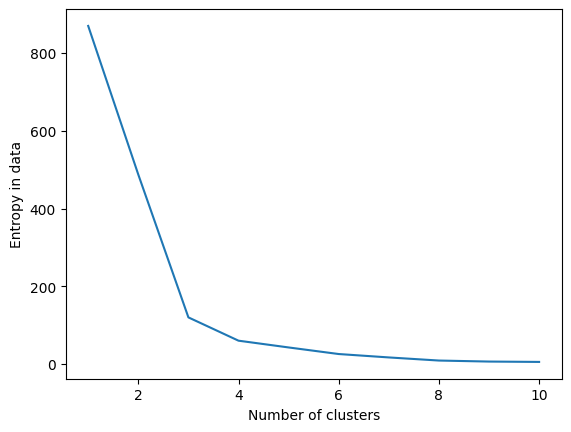

In [44]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
     km = KMeans(n_clusters=i)
     km.fit_predict(Group_data)
     wcss.append(km.inertia_)
fig, ax = plt.subplots()

ax.plot(range(1,11),wcss)

ax.set_xlabel('Number of clusters')
ax.set_ylabel('Entropy in data')

plt.show()

The `Group_data` DataFrame, containing the mean `max_slow` per `type`, is used for clustering.

In [45]:
Group_data

,max_slow
type,
A148,64.047500
A20N,65.600002
A21N,68.266666
A310,69.450001
A318,66.206250
A319,66.286325
A320,67.010660
A321,70.120305
A332,71.274193


After determining the optimal number of clusters (e.g., 4 in this case), the clusters are assigned back to the `Group_data` and then merged with the main `train` DataFrame as a new `class` feature.

In [47]:
km = KMeans(n_clusters=4)
pred=km.fit_predict(Group_data)
Group_data['class']=pred
Group_data=Group_data.reset_index().drop('max_slow',axis=1)

In [48]:
merged = train.merge(Group_data, on=['type'], how='left')
merged.head()

,timestamp,max_slow,type,model,year,day,month,hour,day_of_week,takeoff,class
0,2022-03-01 00:03:47,70.800003,B738,Boeing 737-800,2022,1,3,0,1,1,1
1,2022-03-01 00:05:02,69.199997,B738,Boeing 737-800,2022,1,3,0,1,0,1
2,2022-03-01 00:06:24,69.599998,B738,Boeing 737-800,2022,1,3,0,1,0,1
3,2022-03-01 00:09:47,71.500000,B738,Boeing 737-800,2022,1,3,0,1,1,1
4,2022-03-01 00:11:43,70.800003,B738,Boeing 737-800,2022,1,3,0,1,1,1


Irrelevant columns like `timestamp`, `type`, `model`, and `year` are dropped. The `class` feature is then one-hot encoded into dummy variables for use in modeling.

In [49]:
merged.columns

Index(['timestamp', 'max_slow', 'type', 'model', 'year', 'day', 'month',
       'hour', 'day_of_week', 'takeoff', 'class'],
      dtype='object')

In [50]:
merged.drop(['timestamp', 'type', 'model', 'year'],axis=1,inplace=True)

In [51]:
merged['Index']=range(len(merged))
merged=merged.set_index('Index')
Class=pd.get_dummies(merged['class']).add_prefix('Class_airplane')
merged=merged.merge(Class,on='Index')
merged=merged.drop(['class'],axis=1)

In [52]:
merged

,max_slow,day,month,hour,day_of_week,takeoff,Class_airplane0,Class_airplane1,Class_airplane2,Class_airplane3
Index,,,,,,,,,,
0,70.800003,1,3,0,1,1,False,True,False,False
1,69.199997,1,3,0,1,0,False,True,False,False
2,69.599998,1,3,0,1,0,False,True,False,False
3,71.500000,1,3,0,1,1,False,True,False,False
4,70.800003,1,3,0,1,1,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
6668,66.000000,28,5,22,5,1,True,False,False,False
6669,68.000000,28,5,23,5,0,False,True,False,False
6670,69.400002,28,5,23,5,1,False,True,False,False


## 7. Correlation Analysis and Statistical Tests

This section explores the relationships between features and the target variable.

In [55]:
def cor_with_features(dataset,target,amount):
  correlation = dataset.corr()
  cols = correlation.nlargest(amount,target)[target].index
  cm = dataset[cols].corr()
  f , ax = plt.subplots(figsize = (14,12))
  sns.heatmap(cm, vmax=.8, linewidths=0.01,square=True,annot=True,cmap='viridis',
            linecolor="white",xticklabels = cols.values ,annot_kws = {'size':12},yticklabels = cols.values)
  return plt.show()

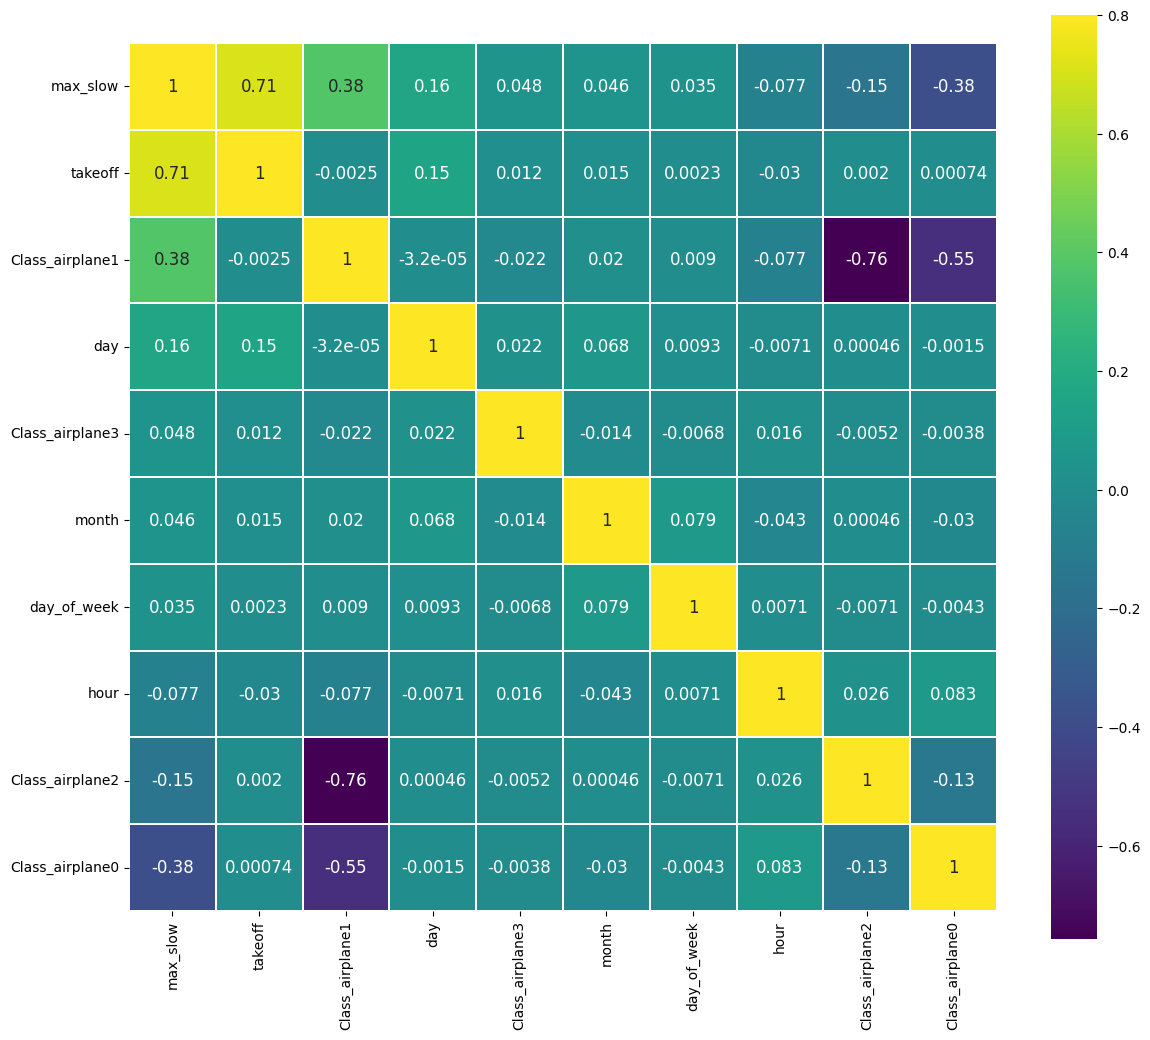

In [56]:
cor_with_features(merged,'max_slow',10)

A correlation heatmap visualizes the relationships between `max_slow` and other features, helping to identify strong predictors.

In [57]:
def test_mw(dataset,target,feature):
     stat, p = mannwhitneyu(dataset[feature], dataset[target])
     print('Mann-Whitney test=%.3f, p=%.3f' % (stat, p))
     alpha = 0.05
     if p > alpha:
       print('You cannot reject the null hypothesis')
     else:
       print('Reject the null hypothesis')

In [58]:
merged.columns

Index(['max_slow', 'day', 'month', 'hour', 'day_of_week', 'takeoff',
       'Class_airplane0', 'Class_airplane1', 'Class_airplane2',
       'Class_airplane3'],
      dtype='object')

In [59]:
for feature in merged.columns:
  test_mw(merged,'max_slow',feature)

Mann-Whitney test=22264464.500, p=1.000
You cannot reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis
Mann-Whitney test=0.000, p=0.000
Reject the null hypothesis


The Mann-Whitney U test is performed to assess if there are significant differences in the distribution of `max_slow` with respect to other features. This non-parametric test is suitable when normality assumptions are not met.

In [60]:
y=merged['max_slow']
x=merged.drop(['max_slow'],axis=1)

## 8. Model Training and Evaluation

This section prepares the data for modeling, trains several baseline regression models, and evaluates their performance.

In [61]:
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=42)

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [62]:
df_models = pd.DataFrame(data=None, columns=['Algorithm', 'MSE', 'MAE'])

def make_model(X_tr, X_te, y_tr, y_te, model, model_name: str):
    model.fit(X_tr, y_tr)
    y_pred=model.predict(X_te)
    MSE=mean_squared_error(y_te,y_pred)
    MAE=mean_absolute_error(y_te, y_pred)
    df_models.loc[len(df_models.index)] = [model_name, MSE, MAE]

In [63]:
models = [RandomForestRegressor(),ElasticNet(), KNeighborsRegressor(),xgb.XGBRegressor()]

In [64]:
for model in models:
    make_model(X_train, X_test, y_train, y_test, model, f'{model}'[:10])

A function `make_model` is defined to streamline the training and evaluation of different regression models (RandomForestRegressor, ElasticNet, KNeighborsRegressor, XGBRegressor). The Mean Squared Error (MSE) and Mean Absolute Error (MAE) are used as evaluation metrics.

In [65]:
fig = go.Figure(data=[
     go.Bar(name='MSE', x=df_models.Algorithm, y=df_models.MSE),
     go.Bar(name='MAE', x=df_models.Algorithm, y=df_models.MAE)
])
fig.update_layout(height=900, width=1400,title='MAE and MSE for various models', title_x=0.5)

## 9. Hyperparameter Tuning with Optuna

This section uses Optuna, an automatic hyperparameter optimization framework, to find the best set of hyperparameters for the XGBoost model to minimize Mean Squared Error (MSE).

The performance of the baseline models is visualized using a bar chart comparing their MSE and MAE scores.

In [90]:
def objective(trial,data=x,target=y):
    train_x, test_x, train_y, test_y=train_test_split(x,y,test_size=0.1,random_state=42)

    param = {
        'lambda': trial.suggest_loguniform('lambda', 1e-3, 10.0),
        'alpha': trial.suggest_loguniform('alpha', 1e-3, 10.0),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0]),
        'subsample': trial.suggest_categorical('subsample', [0.4,0.5,0.6,0.7,0.8,1.0]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.008,0.01,0.012,0.014,0.016,0.018, 0.02]),
        'n_estimators': 10000,
        'max_depth': trial.suggest_categorical('max_depth', [5,7,9,11,13,15,17]),
        'random_state': trial.suggest_categorical('random_state', [2020]),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 300),
    }
    model = xgb.XGBRegressor(**param)

    # Removing early stopping to resolve persistent TypeErrors due to inconsistent XGBoost environment behavior
    model.fit(train_x,train_y,eval_set=[(test_x,test_y)], verbose=False)

    preds = model.predict(test_x)

    mse = mean_squared_error(test_y, preds)

    return mse

The `objective` function defines the process for evaluating a set of hyperparameters. It takes trial object as input, suggests parameters, trains an `XGBRegressor` model, and returns the validation MSE. Early stopping was temporarily removed due to environment incompatibilities.

### Optuna Hyperparameter Optimization

Now that the `objective` function is defined, we can run the Optuna study to find the best hyperparameters for our `XGBRegressor` model. The study will minimize the Mean Squared Error (MSE).

In [98]:
# Print XGBoost version (for debugging environment if needed)
print(f"XGBoost version: {xgb.__version__}")

# Create an Optuna study and optimize the objective function
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Get the history of all trials
hist = study.trials_dataframe()

# Display best trial information and a snippet of the history
print('\nNumber of final trial:', len(study.trials))
print(f'Best trial: MSE= {study.best_trial.value},\nparams {study.best_trial.params}')

print('\nOptuna study history (first 5 rows):')
display(hist.head())

[I 2026-08-15 03:15:55,095] A new study created in memory with name: no-name-af057d85-9749-4660-a2c0-80da44625c40


XGBoost version: 3.3.0


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-08-15 03:16:04,588] Trial 0 finished with value: 5.253252605018863 and parameters: {'lambda': 0.9875475511936724, 'alpha': 0.0048701793324997, 'colsample_bytree': 0.4, 'subsample': 0.8, 'learning_rate': 0.014, 'max_depth': 15, 'random_state': 2020, 'min_child_weight': 299}. Best is trial 0 with value: 5.253252605018863.
[I 2026-08-15 03:16:19,470] Trial 1 finished with value: 5.0409738877084775 and parameters: {'lambda': 0.007244024214341035, 'alpha': 0.0132903917548902, 'colsample_bytree': 0.4, 'subsample': 0.8, 'learning_rate': 0.008, 'max_depth': 15, 'random_state': 2020, 'min_child_weight': 64}. Best is trial 1 with value: 5.0409738877084775.
[I 2026-08-15 03:16:29,897] Trial 2 finished with value: 5.263467472564928 and parameters: {'lambda': 0.0027885012063684276, 'alpha': 0.0013379301982385193, 'colsample_bytree': 0.5, 'subsample': 0.6, 'learning_rate': 0.008, 'max_depth': 15, 'random_state': 2020, 'min_child_weight': 250}. Best is trial 1 with value: 5.0409738877084775.


,number,value,datetime_start,datetime_complete,duration,params_alpha,params_colsample_bytree,params_lambda,params_learning_rate,params_max_depth,params_min_child_weight,params_random_state,params_subsample,state
0,0,5.253253,2026-08-15 03:15:55.151316,2026-08-15 03:16:04.588344,0 days 00:00:09.437028,0.004870,0.4,0.987548,0.014,15,299,2020,0.8,COMPLETE
1,1,5.040974,2026-08-15 03:16:04.592371,2026-08-15 03:16:19.470455,0 days 00:00:14.878084,0.013290,0.4,0.007244,0.008,15,64,2020,0.8,COMPLETE
2,2,5.263467,2026-08-15 03:16:19.474356,2026-08-15 03:16:29.896976,0 days 00:00:10.422620,0.001338,0.5,0.002789,0.008,15,250,2020,0.6,COMPLETE
3,3,5.125693,2026-08-15 03:16:29.902809,2026-08-15 03:16:42.573454,0 days 00:00:12.670645,7.859859,0.6,0.752246,0.018,9,43,2020,0.5,COMPLETE
4,4,5.240580,2026-08-15 03:16:42.579439,2026-08-15 03:16:52.854338,0 days 00:00:10.274899,0.003825,0.4,0.005154,0.016,15,190,2020,0.5,COMPLETE


After running the Optuna study for 100 trials, the best trial's parameters and its corresponding MSE are printed. The `hist` DataFrame contains the full history of all trials, offering a detailed log of the optimization process.

### Visualizations of Optuna Study

To understand the hyperparameter optimization process and the relationships between parameters and the objective value, we can generate several visualizations using Optuna's built-in plotting functions. These plots are interactive (if running in an environment with Plotly support).

1.  **Optimization History Plot**: Shows the objective value (MSE) for each trial, helping to visualize the progression and convergence of the search.
2.  **Hyperparameter Importance Plot**: Ranks hyperparameters by their importance in influencing the objective value, indicating which parameters are most critical to the model's performance.
3.  **Slice Plot**: Illustrates the relationship between individual hyperparameters and the objective value across all trials, useful for identifying optimal ranges.
4.  **Parallel Coordinate Plot**: Provides a comprehensive view of all trials, showing relationships between multiple hyperparameters and the objective value simultaneously.

In [99]:
# Plotting Optimization History
fig_history = optuna.visualization.plot_optimization_history(study)
fig_history.show()

In [100]:
# Plotting Hyperparameter Importance
fig_importance = optuna.visualization.plot_param_importances(study)
fig_importance.show()

In [101]:
# Plotting Slice Plot
fig_slice = optuna.visualization.plot_slice(study)
fig_slice.show()

In [102]:
# Plotting Parallel Coordinate Plot
fig_parallel = optuna.visualization.plot_parallel_coordinate(study)
fig_parallel.show()

## 10. Conclusion and Further Development

This notebook has covered the end-to-end process of analyzing noise data and building a predictive model for `max_slow`:

*   **Data Preparation:** Initial cleaning, datetime feature extraction, and `takeoff` feature creation were performed.
*   **Exploratory Data Analysis:** Distributions of `max_slow` were explored, and statistical tests (Shapiro-Wilk, Mann-Whitney U) were conducted. Correlation analysis helped identify relationships between features.
*   **Feature Engineering:** K-Means clustering was applied to group similar aircraft types based on their mean `max_slow`, creating a new categorical feature.
*   **Model Training:** Several baseline regression models were trained, and their performance was evaluated using MSE and MAE.
*   **Hyperparameter Optimization:** Optuna was used to tune the `XGBRegressor` model, resulting in a set of optimal parameters that yielded a significantly lower MSE compared to the baseline.

### Further Development:

1.  **Re-evaluate Early Stopping:** Investigate and resolve the `XGBoost` early stopping issue to incorporate it back into the Optuna objective function. This could lead to faster and potentially better optimization.
2.  **Feature Importance:** Analyze the feature importance from the best `XGBRegressor` model to understand which features are most critical for `max_slow` prediction.
3.  **Cross-Validation:** Implement k-fold cross-validation within the Optuna objective function for more robust evaluation of hyperparameters.
4.  **Ensemble Methods:** Explore stacking or blending different models for potentially improved performance.
5.  **Deployment:** Consider deploying the best-performing model as an API for real-time predictions.
6.  **Anomaly Detection:** Use the model's predictions to identify unusual noise events (e.g., actual `max_slow` significantly different from predicted `max_slow`).